# Macro Conditioning Features — Welch-Goyal Variables

Builds the 4 Welch-Goyal macro covariates used in the MarketGANs paper from free public sources:

| Variable | Definition | Source |
|----------|-----------|--------|
| `tbl` | 3-month T-bill rate | FRED (`TB3MS`) |
| `tms` | Term spread = 10Y Treasury − 3M T-bill | FRED (`GS10` − `TB3MS`) |
| `dfy` | Default spread = Baa − Aaa corporate yield | FRED (`BAA` − `AAA`) |
| `svar` | Monthly realized stock variance (sum of squared daily S&P 500 returns) | Yahoo Finance (`^GSPC`) |

Output: `data/macro/welch_goyal_features.csv` — daily, z-score normalized, 2011–2025.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt

MACRO_DIR  = Path('../data/macro')
START      = '2010-01-01'   # extra history for ffill warmup
END        = '2025-12-31'
CLIP_START = '2011-01-01'   # align with returns data

MACRO_DIR.mkdir(parents=True, exist_ok=True)
print('Ready.')

Ready.


## 1. FRED — tbl, tms, dfy

In [18]:
print('Downloading FRED series...')

tb3ms = web.DataReader('TB3MS', 'fred', START, END)   # 3M T-bill (monthly)
gs10  = web.DataReader('GS10',  'fred', START, END)   # 10Y Treasury (monthly)
baa   = web.DataReader('BAA',   'fred', START, END)   # Moody's Baa yield (monthly)
aaa   = web.DataReader('AAA',   'fred', START, END)   # Moody's Aaa yield (monthly)

fred = pd.DataFrame({
    'tbl': tb3ms['TB3MS'],
    'tms': gs10['GS10'] - tb3ms['TB3MS'],    # term spread
    'dfy': baa['BAA']   - aaa['AAA'],        # default spread
})

print(f'FRED shape : {fred.shape}')
print(f'Date range : {fred.index.min().date()} → {fred.index.max().date()}')
print(f'NaNs       : {fred.isna().sum().to_dict()}')
fred.tail()

FRED shape : (192, 3)
Date range : 2010-01-01 → 2025-12-01
NaNs       : {'tbl': 0, 'tms': 0, 'dfy': 0}


,tbl,tms,dfy
DATE,,,
2025-08-01,4.12,0.14,0.65
2025-09-01,3.92,0.20,0.62
2025-10-01,3.82,0.24,0.61
2025-11-01,3.78,0.31,0.60
2025-12-01,3.59,0.55,0.59


## 2. Yahoo Finance — svar (realized stock variance)

In [19]:
print('Downloading S&P 500 from Yahoo Finance...')

sp500 = yf.download('^GSPC', start=START, end=END,
                    auto_adjust=True, progress=False)

if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500_ret = np.log(sp500['Close'] / sp500['Close'].shift(1)).dropna()

# svar = sum of squared daily returns within each calendar month
svar_monthly = (sp500_ret ** 2).resample('MS').sum().rename('svar')

print(f'S&P 500 daily returns : {len(sp500_ret)} days')
print(f'svar monthly shape    : {svar_monthly.shape}')
print(f'Date range            : {svar_monthly.index.min().date()} → {svar_monthly.index.max().date()}')
svar_monthly.tail()

S&P 500 daily returns : 4022 days
svar monthly shape    : (192,)
Date range            : 2010-01-01 → 2025-12-01


Date
2025-08-01    0.001140
2025-09-01    0.000458
2025-10-01    0.001660
2025-11-01    0.001703
2025-12-01    0.000596
Freq: MS, Name: svar, dtype: float64

## 3. Merge & forward-fill monthly → daily

In [20]:
# Align all monthly series to month-start
# FRED returns month-start timestamps already; normalize both to be safe
fred.index = fred.index.to_period('M').to_timestamp()
svar_monthly.index = svar_monthly.index.to_period('M').to_timestamp()

monthly = fred.join(svar_monthly, how='outer').sort_index()

print('Monthly shape:', monthly.shape)
print('NaNs per column:')
print(monthly.isna().sum().to_string())
monthly.tail()

Monthly shape: (192, 4)
NaNs per column:
tbl     0
tms     0
dfy     0
svar    0


,tbl,tms,dfy,svar
DATE,,,,
2025-08-01,4.12,0.14,0.65,0.001140
2025-09-01,3.92,0.20,0.62,0.000458
2025-10-01,3.82,0.24,0.61,0.001660
2025-11-01,3.78,0.31,0.60,0.001703
2025-12-01,3.59,0.55,0.59,0.000596


In [21]:
# Forward-fill monthly → business days
daily_index = pd.date_range(start=CLIP_START, end=END, freq='B')

macro_daily = (
    monthly
    .reindex(monthly.index.union(daily_index))
    .ffill()
    .reindex(daily_index)
)

# bfill for any gaps at the very start
macro_daily = macro_daily.bfill()

print(f'Daily shape : {macro_daily.shape}')
print(f'Date range  : {macro_daily.index.min().date()} → {macro_daily.index.max().date()}')
print(f'NaNs        : {macro_daily.isna().sum().sum()}')
macro_daily.tail()

Daily shape : (3913, 4)
Date range  : 2011-01-03 → 2025-12-31
NaNs        : 0


,tbl,tms,dfy,svar
2025-12-25,3.59,0.55,0.59,0.000596
2025-12-26,3.59,0.55,0.59,0.000596
2025-12-29,3.59,0.55,0.59,0.000596
2025-12-30,3.59,0.55,0.59,0.000596
2025-12-31,3.59,0.55,0.59,0.000596


## 4. Validate & visualize

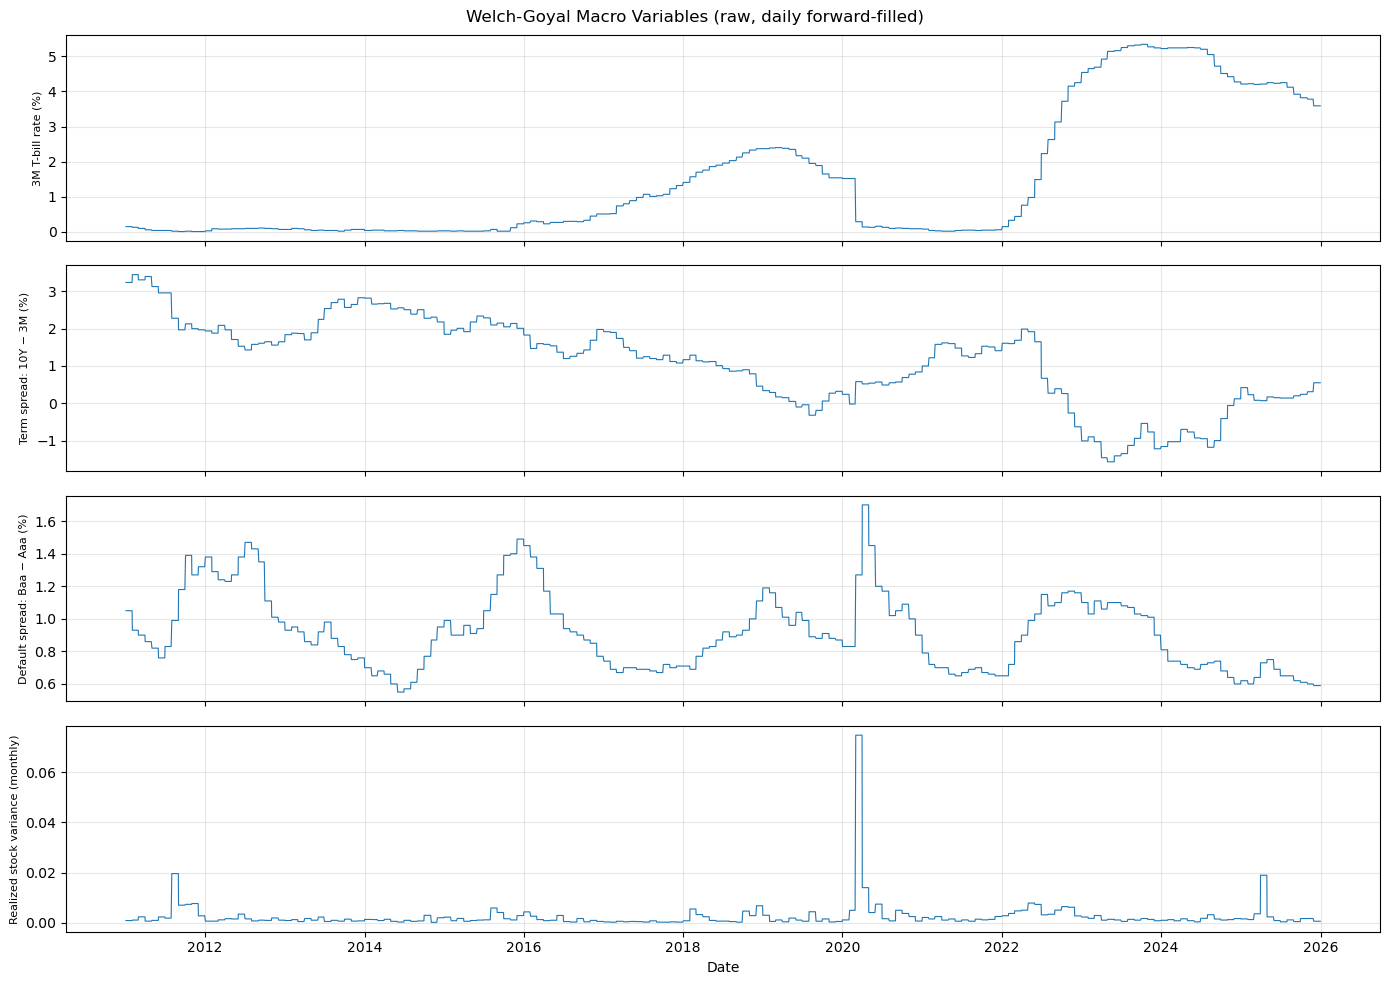


Descriptive stats:


,tbl,tms,dfy,svar
count,3913.0000,3913.0000,3913.0000,3913.0000
mean,1.4715,1.1006,0.9189,0.0025
std,1.8372,1.1602,0.2354,0.0061
min,0.0100,-1.5700,0.5500,0.0001
25%,0.0500,0.2400,0.7100,0.0007
50%,0.3000,1.2900,0.9000,0.0012
75%,2.3700,1.9400,1.0700,0.0025
max,5.3400,3.4500,1.7000,0.0747


In [22]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

labels = {
    'tbl':  '3M T-bill rate (%)',
    'tms':  'Term spread: 10Y − 3M (%)',
    'dfy':  'Default spread: Baa − Aaa (%)',
    'svar': 'Realized stock variance (monthly)',
}

for ax, (col, label) in zip(axes, labels.items()):
    ax.plot(macro_daily.index, macro_daily[col], linewidth=0.8)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Welch-Goyal Macro Variables (raw, daily forward-filled)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nDescriptive stats:')
macro_daily.describe().round(4)

## 5. Z-score normalize & save

In [23]:
macro_norm = (macro_daily - macro_daily.mean()) / macro_daily.std()

print('After normalization — mean (should be ~0):')
print(macro_norm.mean().round(6).to_string())
print('\nAfter normalization — std (should be ~1):')
print(macro_norm.std().round(6).to_string())

# Correlation check
print('\nPairwise correlations:')
print(macro_norm.corr().round(2).to_string())

After normalization — mean (should be ~0):
tbl     0.0
tms     0.0
dfy     0.0
svar    0.0

After normalization — std (should be ~1):
tbl     1.0
tms     1.0
dfy     1.0
svar    1.0

Pairwise correlations:
       tbl   tms   dfy  svar
tbl   1.00 -0.87 -0.17 -0.05
tms  -0.87  1.00 -0.00 -0.04
dfy  -0.17 -0.00  1.00  0.23
svar -0.05 -0.04  0.23  1.00


In [24]:
out_path = MACRO_DIR / 'welch_goyal_features.csv'
macro_norm.index.name = 'Date'
macro_norm.to_csv(out_path)

print(f'Saved → {out_path}')
print(f'Shape : {macro_norm.shape}')
print(f'Cols  : {macro_norm.columns.tolist()}')
macro_norm.head()

Saved → ../data/macro/welch_goyal_features.csv
Shape : (3913, 4)
Cols  : ['tbl', 'tms', 'dfy', 'svar']


,tbl,tms,dfy,svar
Date,,,,
2011-01-03,-0.719311,1.844086,0.556842,-0.272041
2011-01-04,-0.719311,1.844086,0.556842,-0.272041
2011-01-05,-0.719311,1.844086,0.556842,-0.272041
2011-01-06,-0.719311,1.844086,0.556842,-0.272041
2011-01-07,-0.719311,1.844086,0.556842,-0.272041
